In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve


In [2]:
# Load Preprocessed Data
file_path = "../../data/jm_preprocessed_churn_data.csv"
df = pd.read_csv(file_path)
print("Preprocessed data loaded.")


Preprocessed data loaded.


## Data Preparation , Encoding

In [ ]:
features_to_drop = ["CustomerID", "Count", "Country", "State", "City", "Zip Code",
                    "Lat Long", "Latitude", "Longitude", "Churn Label",
                    "Churn Value", "Churn Score", "Churn_Numeric", "Churn Reason", "Churn_Probability"]

X = df.drop(columns=[c for c in features_to_drop if c in df.columns])
y = df["Churn_Numeric"]

le = LabelEncoder()
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set size: {X_train.shape}, Test set size: {X_test.shape}")


Train set size: (5634, 20), Test set size: (1409, 20)


## LightGMB, Random Forest 모델

In [4]:

# LightGBM
lgbm_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31
)
lgbm_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=4
)
rf_model.fit(X_train, y_train)
print("Individual models trained.")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000506 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 881
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
Individual models trained.


In [5]:
# Ensemble
voting_model = VotingClassifier(
    estimators=[("lgbm", lgbm_model), ("rf", rf_model)],
    voting="soft"
)
voting_model.fit(X_train, y_train)
print("Ensemble model trained.")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 881
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
Ensemble model trained.


## AUC Score

In [6]:
y_pred_voting = voting_model.predict(X_test)
y_pred_proba_voting = voting_model.predict_proba(X_test)[:, 1]

print("--- Ensemble (Voting) Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_voting):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba_voting):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))


--- Ensemble (Voting) Model Evaluation ---
Accuracy: 0.8048
AUC Score: 0.8519

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [8]:
from sklearn.metrics import roc_auc_score, roc_curve

# 최종 앙상블 모델의 예측 확률값 사용
y_pred_proba_final = voting_model.predict_proba(X_test)[:, 1]

# AUC 계산
auc_score_final = roc_auc_score(y_test, y_pred_proba_final)

print(f'최종 앙상블 모델의 AUC Score: {auc_score_final:.4f}')

최종 앙상블 모델의 AUC Score: 0.8519


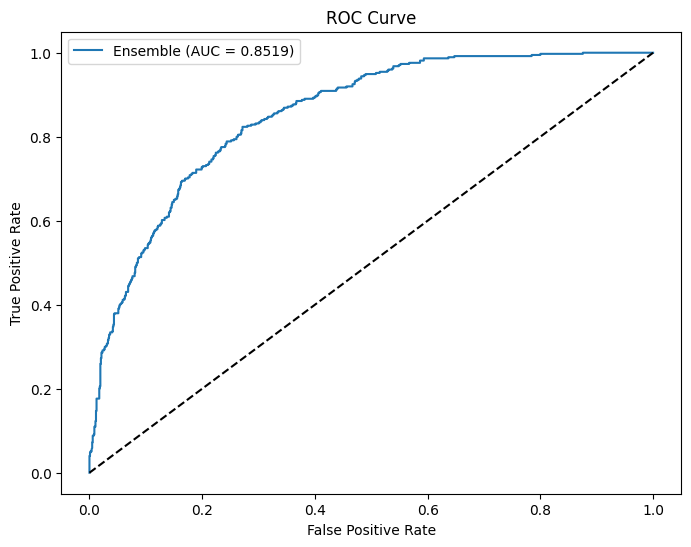

In [7]:
# Visualization: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_voting)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Ensemble (AUC = {roc_auc_score(y_test, y_pred_proba_voting):.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
